In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
import pandas as pd
uploaded=files.upload()
filename=next(iter(uploaded))
data=pd.read_csv(filename)
print("Dataset Shape:",data.shape)
display(data.head())

Saving 02-logistic-regression-dataset-task-2.csv to 02-logistic-regression-dataset-task-2.csv
Dataset Shape: (36, 4)


,Disease,Age,Gender,Smoker_status
0,diseased,43,Male,Smoker
1,not diseased,18,Male,Smoker
2,diseased,22,Female,Non-smoker
3,diseased,25,Male,Non-smoker
4,not diseased,45,Female,Smoker


In [3]:
print("\nNull values in dataset:")
print(data.isnull().sum())


Null values in dataset:
Disease          0
Age              0
Gender           0
Smoker_status    0
dtype: int64


In [4]:
X=data.iloc[:,:-1]
y=data.iloc[:,-1]
encoder=LabelEncoder()
y=encoder.fit_transform(y)
print("\nClasses identified in the target variable:",encoder.classes_)


Classes identified in the target variable: ['Non-smoker' 'Smoker']


In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=5)
print("\nShapes of splits (X_train,y_train,X_test,y_test):")
display(X_train.shape,y_train.shape,X_test.shape,y_test.shape)
X=pd.get_dummies(X,drop_first=True)


Shapes of splits (X_train,y_train,X_test,y_test):


(28, 3)

(28,)

(8, 3)

(8,)

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=5)
print("\nShapes of splits (X_train,y_train,X_test,y_test):")
display(X_train.shape,y_train.shape,X_test.shape,y_test.shape)


Shapes of splits (X_train,y_train,X_test,y_test):


(28, 3)

(28,)

(8, 3)

(8,)

In [7]:
model=LogisticRegression(solver='lbfgs',max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [8]:
conf_mat=metrics.confusion_matrix(y_test,y_pred)
print('\nConfusion Matrix:\n',conf_mat)
accuracy=metrics.accuracy_score(y_test,y_pred)
print('Accuracy Score:',accuracy)
print('Accuracy in Percentage:',int(accuracy*100),'%')


Confusion Matrix:
 [[1 2]
 [0 5]]
Accuracy Score: 0.75
Accuracy in Percentage: 75 %


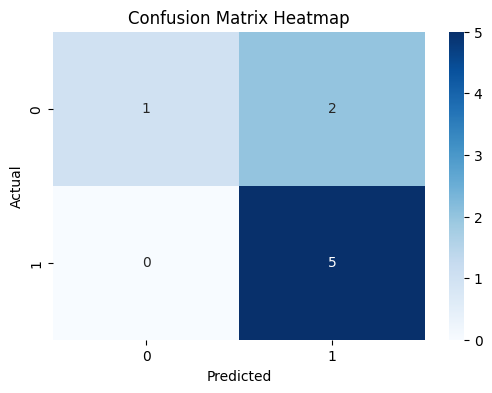

In [9]:
conf_mat_df=pd.crosstab(y_test,y_pred,rownames=['Actual'],colnames=['Predicted'])
plt.figure(figsize=(6,4))
sns.heatmap(conf_mat_df,annot=True,cmap='Blues',fmt='g')
plt.title('Confusion Matrix Heatmap')
plt.show()